In [1]:
%pip install -q pennylane qiskit qiskit-aer matplotlib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 907.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 20.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 48.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 68.5 MB/s eta 0:00:0000:01:00:01


In [2]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## VQE Ground state energy of H2

Loads info for the H2 molecule, including the molecular hamiltonian and the number of qubits needed to represent the electronic H2 wavefunction. Each qubit is one spin orbital which for H2 is 4. 

In [3]:
## Pennylane toutorial Hamiltonian
from jax import numpy as np
import jax
jax.config.update("jax_platform_name", "cpu")
jax.config.update('jax_enable_x64', True)

import pennylane as qp

dataset = qp.data.load('qchem', molname="H2")[0]
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)
print("Number of qubits = ", qubits)
print("The Hamiltonian is ", H)

Number of qubits =  4
The Hamiltonian is  -0.09963387941370971 * I(0) + 0.17110545123720233 * Z(0) + 0.17110545123720225 * Z(1) + 0.16859349595532533 * (Z(0) @ Z(1)) + 0.04533062254573469 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.04533062254573469 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.04533062254573469 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.04533062254573469 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.22250914236600539 * Z(2) + 0.12051027989546245 * (Z(0) @ Z(2)) + -0.22250914236600539 * Z(3) + 0.16584090244119712 * (Z(0) @ Z(3)) + 0.16584090244119712 * (Z(1) @ Z(2)) + 0.12051027989546245 * (Z(1) @ Z(3)) + 0.1743207725924201 * (Z(2) @ Z(3))


We are trying to figure out what the optimal angluar rotation of the molecules is to create a minimized energy when they are .7 angstroms apart.

We start with the Hartree-Fock state |1100> (only the first two orbitals are occupied). The rotation angle (theta) then changes the state, the cost function computes a new energy, and the optimizer updates the rotation angle. The optimal theta value is found when continuing to change theta only makes the energy go up. The ground state energy estimate using this optimal rotation angle is the lowest eigenvalue of the Hamiltonian.

Number of qubits: 4
Optimal parameter: [0.20968899]
Final energy: -1.1361895475277854 Ha


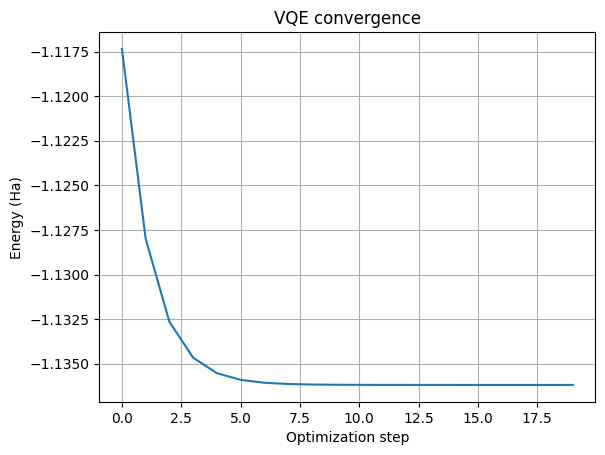

In [4]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Load H2 Hamiltonian
dataset = qml.data.load("qchem", molname="H2", bondlength=0.7)[0]
H = dataset.hamiltonian

qubits = len(H.wires)
print("Number of qubits:", qubits)

electrons = 2
hf_state = qml.qchem.hf_state(electrons, qubits)

def ansatz(params):
    qml.BasisState(hf_state, wires=range(qubits))

    qml.DoubleExcitation(params[0], wires=[0, 1, 2, 3])

dev = qml.device("default.qubit", wires=qubits)

@qml.qnode(dev)
def cost(params):
    ansatz(params)
    return qml.expval(H)

params = np.array([0.0], requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.4)

energies = []

for step in range(20):
    params, e = opt.step_and_cost(cost, params)
    energies.append(e)

print("Optimal parameter:", params)
print("Final energy:", energies[-1], "Ha")

plt.plot(energies)
plt.xlabel("Optimization step")
plt.ylabel("Energy (Ha)")
plt.title("VQE convergence")
plt.grid()
plt.show()

In the following code I try changing the bond lengths of the H atoms to see where the minimum energy occurs. At very small seperation H2 has high energy and is thus unstable, and when you move the molecules too far away from eachother they won't interact with one another and the curve will approach E(H) + E(H). When the energy is at a minimum the system is at equilibrium because the repulsive forces will be balanced. 

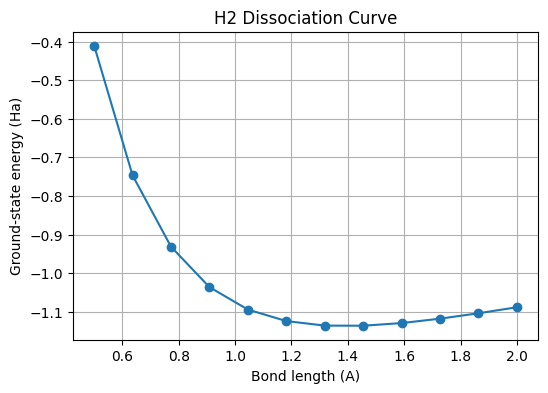

In [5]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Bond lengths
bond_lengths = np.linspace(0.5, 2.0, 12)
energies_final = []

electrons = 2

for R in bond_lengths:

    # H2 Hamiltonian from geometry
    symbols = ["H", "H"]
    coordinates = np.array([[0.0, 0.0, 0.0],
                             [0.0, 0.0, R]])

    H, qubits = qml.qchem.molecular_hamiltonian(symbols, coordinates)

    # Hartree fock
    hf_state = qml.qchem.hf_state(electrons, qubits)

    # ansatz
    dev = qml.device("default.qubit", wires=qubits)
    def ansatz(params):
        qml.BasisState(hf_state, wires=range(qubits))
        qml.DoubleExcitation(params[0], wires=[0, 1, 2, 3])

    # cost func
    @qml.qnode(dev)
    def cost(params):
        ansatz(params)
        return qml.expval(H)

    # parameters
    params = np.array([0.0], requires_grad=True)

    # Optimizer
    opt = qml.GradientDescentOptimizer(stepsize=0.4)
    for step in range(50):
        params, energy = opt.step_and_cost(cost, params)
    energies_final.append(cost(params))

# graph
plt.figure(figsize=(6,4))
plt.plot(bond_lengths, energies_final, "o-")
plt.xlabel("Bond length (A)")
plt.ylabel("Ground-state energy (Ha)")
plt.title("H2 Dissociation Curve")
plt.grid(True)
plt.show()

## QAOA
---

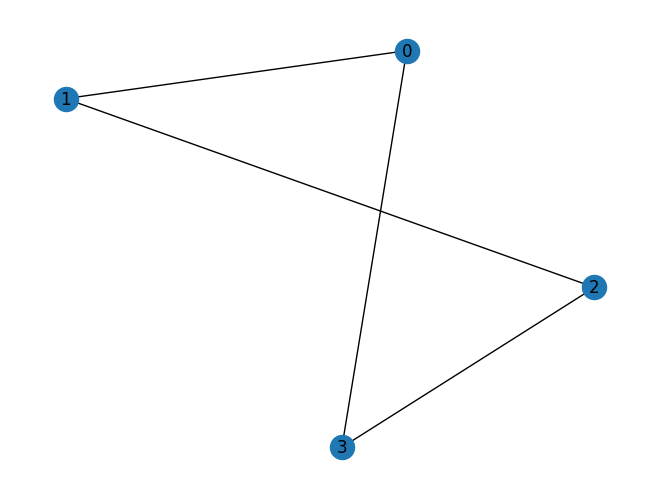

Step 10: Cost = -2.922000
Step 20: Cost = -1.166000
Step 30: Cost = -2.988000
Step 40: Cost = -2.020000
Step 50: Cost = -2.468000
Step 60: Cost = -3.038000

Optimized parameters:
[[ 2.335]
 [-2.813]]


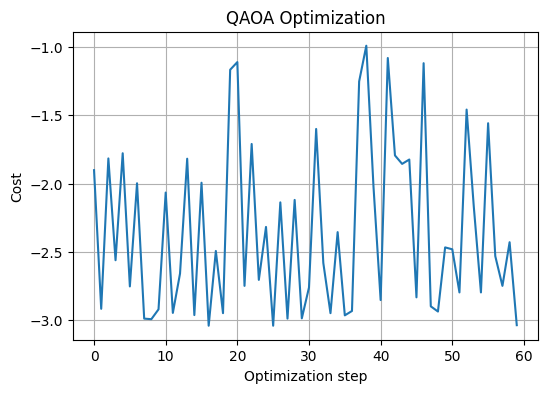

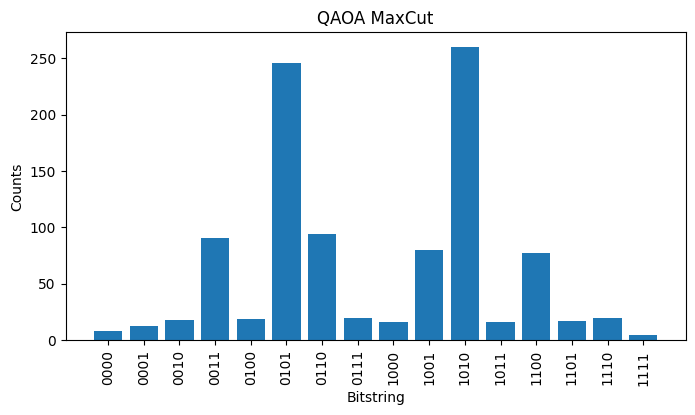

{np.str_('0000'): np.int64(8), np.str_('0001'): np.int64(13), np.str_('0010'): np.int64(18), np.str_('0011'): np.int64(91), np.str_('0100'): np.int64(19), np.str_('0101'): np.int64(246), np.str_('0110'): np.int64(94), np.str_('0111'): np.int64(20), np.str_('1000'): np.int64(16), np.str_('1001'): np.int64(80), np.str_('1010'): np.int64(260), np.str_('1011'): np.int64(16), np.str_('1100'): np.int64(77), np.str_('1101'): np.int64(17), np.str_('1110'): np.int64(20), np.str_('1111'): np.int64(5)}


In [9]:
import pennylane as qml
from pennylane import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Graph
graph = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 0)])
nx.draw(graph, with_labels=True)
plt.show()

# QAOA Hamiltonians
cost_h, mixer_h = qml.qaoa.maxcut(graph)

n_wires = graph.number_of_nodes()

dev = qml.device("default.qubit", wires=n_wires, shots=1000)

def qaoa_layer(gamma, alpha):
    qml.qaoa.cost_layer(gamma, cost_h)
    qml.qaoa.mixer_layer(alpha, mixer_h)

p = 1

def circuit(params):
    # Uniform superposition
    for w in range(n_wires):
        qml.Hadamard(wires=w)

    qml.layer(qaoa_layer, p, params[0], params[1])


@qml.qnode(dev)
def cost_fn(params):
    circuit(params)
    return qml.expval(cost_h)


@qml.qnode(dev)
def sample_fn(params):
    circuit(params)
    return qml.counts()


# Initial parameters
params = np.array([[0.5], [0.5]], requires_grad=True)

# Optimizer
opt = qml.GradientDescentOptimizer(stepsize=0.5)

costs = []

for step in range(60):
    params = opt.step(cost_fn, params)
    energy = cost_fn(params)
    costs.append(energy)

    if (step + 1) % 10 == 0:
        print(f"Step {step+1:2d}: Cost = {energy:.6f}")

print("\nOptimized parameters:")
print(params)

# Plot optimization
plt.figure(figsize=(6,4))
plt.plot(costs)
plt.xlabel("Optimization step")
plt.ylabel("Cost")
plt.title("QAOA Optimization")
plt.grid(True)
plt.show()

# Sample final circuit
counts = sample_fn(params)

# Plot bitstring probabilities
plt.figure(figsize=(8,4))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Bitstring")
plt.ylabel("Counts")
plt.title("QAOA MaxCut")
plt.xticks(rotation=90)
plt.show()

print(counts)

States with many edges crossing the cut have lower expectation value. Therefore, minimizing the expectation value of cost_h is equivalent to maximizing the cut. The hamiltonian mixer's job is to move probability between different bitstrings. Each QAOA layer performs a cost evolution and a mixer evolution. Gamma controls how strongly the graph structure affects the state and alpha controls how much exploration occurs. Initially every cut has equal probability QAOA then gradually shifts probability toward the better cuts.